# ZINC Michael acceptors

## Import necessary packages

In [1]:
import os
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem import Draw
from tqdm import tqdm
# For parallel processing
from pandarallel import pandarallel

# Choose a tranche (chunk) to load
# Choose number of CPUs for parallel processsing
chunk = "00"
ncpu = 10

Failed to find the pandas get_adjustment() function to patch
Failed to patch pandas - PandasTools will have limited functionality


## Data collection / loading

Data was collected from 1/100 tranches of ZINC provided on the HuggingFace platform (https://huggingface.co/datasets/zpn/zinc20).

Before running this notebook, please download the appropriate tranche jsonl.gz file from https://huggingface.co/datasets/zpn/zinc20/tree/main/zinc_processed

Load the chunk selected (contains approx. 10M molecules as SMILES, SELFIES, ZINC_ID)

In [ ]:
# Takes ~ 1 minute to unzip and load (approx. 10M molecules)
file = os.path.join("ZINC",f"smiles_all_{chunk}_clean.jsonl.gz")
df = pd.read_json(file, lines=True)

In [ ]:
print(df.shape)
df.head()

(10071919, 3)


,smiles,id,selfies
0,c1ccc(c(c1)C(=O)OCC[C@@H]2CCCC[NH2+]2)N,ZINC000000000638_1,[C][=C][C][=C][Branch2][Ring1][=Branch1][C][=B...
1,Cc1ccccc1OC[C@@H](C[NH+]2CCC=CC2)O,ZINC000000000794_1,[C][C][=C][C][=C][C][=C][Ring1][=Branch1][O][C...
2,COc1cc(cc(c1OC)OC)/C=C/C(=O)N,ZINC000000001157_1,[C][O][C][=C][C][=Branch1][N][=C][C][=Branch1]...
3,c1cc(=O)[nH]cc1C(=O)N2CCCCC2,ZINC000000003546_1,[C][=C][C][=Branch1][C][=O][NH1][C][=C][Ring1]...
4,c1cc(cnc1)[C@H]2n3ccc(c3CS2)C(=O)N,ZINC000000004355_1,[C][=C][C][=Branch1][=Branch1][=C][N][=C][Ring...


## Filtering ZINC for Michael acceptors

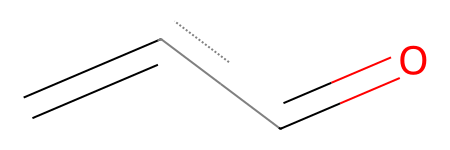

In [ ]:
smarts = "O=CC=C"
patt = Chem.MolFromSmarts(smarts)
patt

In [ ]:
# Takes ~ 3 minutes for full dataset
# (approx. 3 minutes per 10_000_000 compounds)
pandarallel.initialize(nb_workers=ncpu, progress_bar=True)
df["HasMatch"] = df["smiles"].parallel_apply(lambda x: Chem.MolFromSmiles(x).HasSubstructMatch(patt))
Michael_df = df[df["HasMatch"]==True]
del df # clear large df from memory
print(Michael_df.shape)
Michael_df.head()

INFO: Pandarallel will run on 10 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


(262591, 4)


,smiles,id,selfies,HasMatch
2,COc1cc(cc(c1OC)OC)/C=C/C(=O)N,ZINC000000001157_1,[C][O][C][=C][C][=Branch1][N][=C][C][=Branch1]...,True
149,COc1cccc(c1OC)/C=C(\C#N)/C(=O)OC,ZINC000000258138_1,[C][O][C][=C][C][=C][C][=Branch1][=Branch1][=C...,True
295,c1cc(sc1/C=C(/C#N)\C(=O)N)Cl,ZINC000001001869_1,[C][C][=C][Branch1][S][S][C][=Ring1][Branch1][...,True
358,c1ccc(cc1)/C=C/C(=O)N2CCC(=O)NCC2,ZINC000001496287_1,[C][=C][C][=C][Branch1][Branch1][C][=C][Ring1]...,True
408,CCOCCOC(=O)/C=C/c1ccco1,ZINC000001599416_1,[C][C][O][C][C][O][C][=Branch1][C][=O][/C][=C]...,True


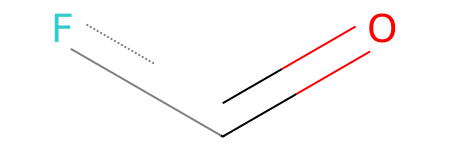

In [ ]:
filter_smarts = ["O=C([OH])C=C","O=C([O-])C=C",
                 "O=C(F)","O=C(Cl)","O=C(Br)","O=C(I)",
                 "O=CC([OH])=C","O=CC=C[OH]",
                 "O=CC([NH2])=C","O=CC=C[NH2]",
                 "O=CC=CC=O"]
filter_mols = [Chem.MolFromSmarts(fs) for fs in filter_smarts]

# from rdkit.Chem.Draw import MolsToGridImage
# MolsToGridImage(mols=filter_mols, legends=filter_smarts, molsPerRow=4)
filter_mols[2]

In [ ]:
# Can be relatively slow, ~ 1 minute
PandasTools.AddMoleculeColumnToFrame(Michael_df, smilesCol='smiles')
tqdm.pandas()
Michael_df["Filter"] = Michael_df["ROMol"].progress_apply(lambda x: any(x.HasSubstructMatch(patt) for patt in filter_mols))

Failed to patch pandas - unable to change molecule rendering
100%|██████████| 262591/262591 [00:02<00:00, 91536.30it/s]


In [ ]:
Michael_df = Michael_df[Michael_df["Filter"]==False]
print(Michael_df.shape)
Michael_df.drop(["HasMatch","ROMol","Filter"], axis=1, inplace=True)
outfile = os.path.join("data","ZINC",f"ZINC_{chunk}_Michael.csv.gz")
Michael_df.to_csv(outfile,index=False,compression='gzip')
Michael_df.head()

(252327, 6)


,smiles,id,selfies
2,COc1cc(cc(c1OC)OC)/C=C/C(=O)N,ZINC000000001157_1,[C][O][C][=C][C][=Branch1][N][=C][C][=Branch1]...
149,COc1cccc(c1OC)/C=C(\C#N)/C(=O)OC,ZINC000000258138_1,[C][O][C][=C][C][=C][C][=Branch1][=Branch1][=C...
295,c1cc(sc1/C=C(/C#N)\C(=O)N)Cl,ZINC000001001869_1,[C][C][=C][Branch1][S][S][C][=Ring1][Branch1][...
358,c1ccc(cc1)/C=C/C(=O)N2CCC(=O)NCC2,ZINC000001496287_1,[C][=C][C][=C][Branch1][Branch1][C][=C][Ring1]...
408,CCOCCOC(=O)/C=C/c1ccco1,ZINC000001599416_1,[C][C][O][C][C][O][C][=Branch1][C][=O][/C][=C]...


## Re-load dataframe and print out some molecules

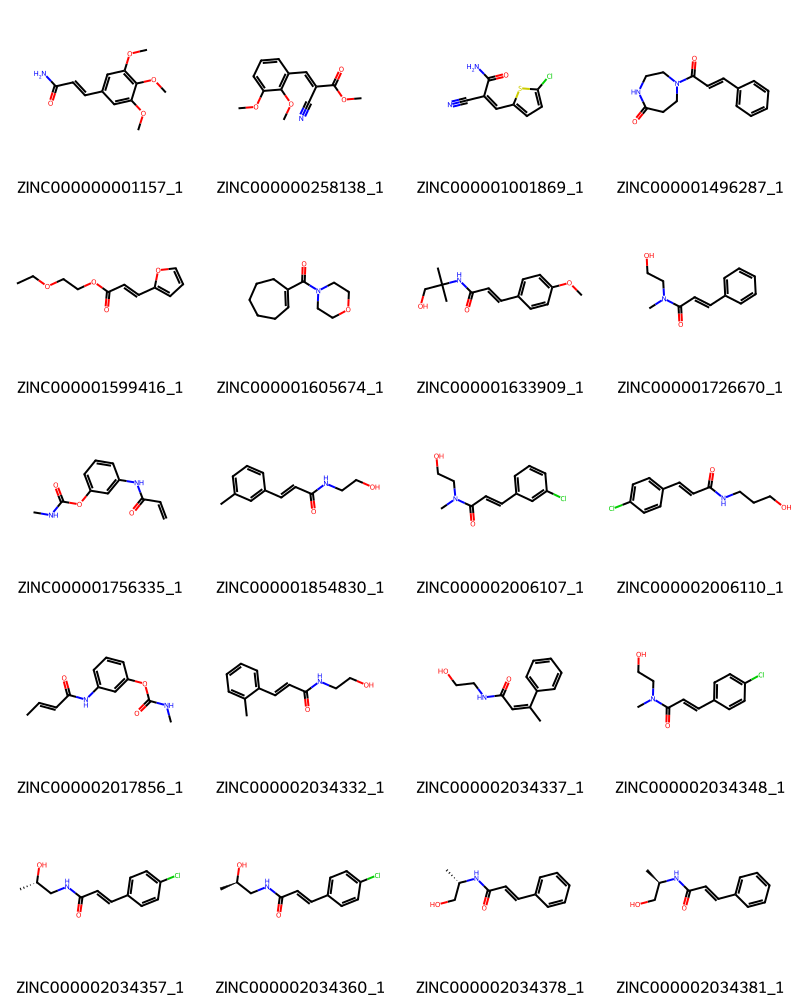

In [ ]:
outfile = str(os.path.join("data","ZINC",f"ZINC_{chunk}_Michael.csv.gz"))
Michael_df = pd.read_csv(outfile, compression="gzip")

m = 20
mols = [Chem.MolFromSmiles(smi) for smi in Michael_df["smiles"].values[:m]]
ids = Michael_df["id"].values[:m]
Draw.MolsToGridImage(mols=mols, legends=ids.tolist(), molsPerRow=4, useSVG=True)

## Make train-valid-test splits and save to SMI format

In [ ]:
# Train-validation-test split

import numpy as np
np.random.seed(42)

n_train = len(Michael_df) - 50_000
n_valid, n_test = 25_000, 25_000
smi_id = Michael_df[["smiles","id"]].values
np.random.shuffle(smi_id)
train = smi_id[:n_train].astype(str)
valid = smi_id[n_train:n_train+n_valid].astype(str)
test = smi_id[n_train+n_valid:].astype(str)

header = np.array([["SMILES","Name"]])
np.savetxt(os.path.join("data","ZINC","train.smi"),
            np.concatenate((header, train)), delimiter=" ", fmt="%s")
np.savetxt(os.path.join("data","ZINC","valid.smi"), 
           np.concatenate((header, valid)), delimiter=" ", fmt="%s")
np.savetxt(os.path.join("data","ZINC","test.smi"), 
           np.concatenate((header, test)), delimiter=" ", fmt="%s")

In [ ]:
with open(os.path.join("data","ZINC","test.smi"), "r") as f:
    lines = f.readlines()[:10]
print("".join(lines))

SMILES Name
C/C=C/C=C/C(=O)N[C@@H](C(C)C)C(=O)NC ZINC000178685422_1
CO[C@@H]1CC[C@H](C1)NC(=O)/C=C/c2cccnc2 ZINC000191615202_1
CC1(CC[C@@H](C1)N(C)C(=O)/C=C/c2ccc3ccccc3n2)C ZINC000794268650_1
c1cc(n2ccnc2c1)COC(=O)C3=COCC3 ZINC000770922636_1
CC/C=C(\C)/C(=O)OC[C@@H]1CCC(=O)N1 ZINC000194835231_1
C/C(=C\C(=O)NC(C)(C)CCO)/Cl ZINC000901243797_1
Cc1ccc(o1)/C=C\C(=O)N2C[C@@H]([C@H](C2)[NH3+])C ZINC000493856509_1
C/C(=C\C(=O)N1CCC[C@H]1c2ccccc2)/c3ccccc3 ZINC000917631132_1
CCCN(CC[NH+]1CCCC1)C(=O)C=C ZINC001335867121_1



## Michael Acceptor Statistics

In [ ]:
# Report the number of amides, esters, ketones, aldehydes in this data set

# 1. Collect number of amides, esters, ketones, aldehydes 
# 2. Plot a bar chart or pie chart 

# AMIDE = C=CC(N)=O # IsAmide
# KETONE = C=CC(C)=O, C=CC(c)=O # IsKetone
# ESTER = C=CC(OC)=O, C=CC(Oc)=O # IsEster
# ALDEHYDE = C=CC([H])=O # IsAldehyde

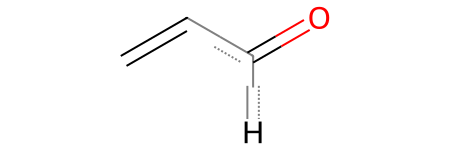

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
mol = Chem.MolFromSmarts("C=CC([H])=O")
mol

In [ ]:
outfile = str(os.path.join("data","ZINC",f"ZINC_{chunk}_Michael.csv.gz"))
Michael_df = pd.read_csv(outfile, compression="gzip")
print(Michael_df.shape)
Michael_df.head()

(252327, 3)


,smiles,id,selfies
0,COc1cc(cc(c1OC)OC)/C=C/C(=O)N,ZINC000000001157_1,[C][O][C][=C][C][=Branch1][N][=C][C][=Branch1]...
1,COc1cccc(c1OC)/C=C(\C#N)/C(=O)OC,ZINC000000258138_1,[C][O][C][=C][C][=C][C][=Branch1][=Branch1][=C...
2,c1cc(sc1/C=C(/C#N)\C(=O)N)Cl,ZINC000001001869_1,[C][C][=C][Branch1][S][S][C][=Ring1][Branch1][...
3,c1ccc(cc1)/C=C/C(=O)N2CCC(=O)NCC2,ZINC000001496287_1,[C][=C][C][=C][Branch1][Branch1][C][=C][Ring1]...
4,CCOCCOC(=O)/C=C/c1ccco1,ZINC000001599416_1,[C][C][O][C][C][O][C][=Branch1][C][=O][/C][=C]...


Amides

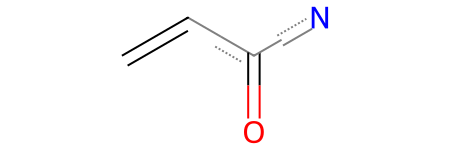

In [ ]:
amide_smarts = "C=CC(=O)N"
amide_patt = Chem.MolFromSmarts(amide_smarts)
amide_patt

In [ ]:
pandarallel.initialize(nb_workers=ncpu, progress_bar=True)
Michael_df["HasAmide"] = Michael_df["smiles"].parallel_apply(lambda x: Chem.MolFromSmiles(x).HasSubstructMatch(amide_patt))
Amide_df = Michael_df[Michael_df["HasAmide"]==True]
print(Amide_df.shape)
Amide_df.head()

INFO: Pandarallel will run on 10 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


(217485, 4)


,smiles,id,selfies,HasAmide
0,COc1cc(cc(c1OC)OC)/C=C/C(=O)N,ZINC000000001157_1,[C][O][C][=C][C][=Branch1][N][=C][C][=Branch1]...,True
2,c1cc(sc1/C=C(/C#N)\C(=O)N)Cl,ZINC000001001869_1,[C][C][=C][Branch1][S][S][C][=Ring1][Branch1][...,True
3,c1ccc(cc1)/C=C/C(=O)N2CCC(=O)NCC2,ZINC000001496287_1,[C][=C][C][=C][Branch1][Branch1][C][=C][Ring1]...,True
5,C1CCC=C(CC1)C(=O)N2CCOCC2,ZINC000001605674_1,[C][C][C][C][=C][Branch1][Branch1][C][C][Ring1...,True
6,CC(C)(CO)NC(=O)/C=C/c1ccc(cc1)OC,ZINC000001633909_1,[C][C][Branch1][C][C][Branch1][Ring1][C][O][N]...,True


Aldehydes

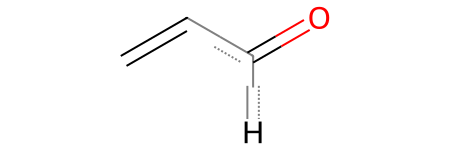

In [ ]:
aldehyde_smarts = "C=CC([H])=O"
aldehyde_patt = Chem.MolFromSmarts(aldehyde_smarts)
aldehyde_patt

In [ ]:
pandarallel.initialize(nb_workers=ncpu, progress_bar=True)
Michael_df["HasAldehyde"] = Michael_df["smiles"].parallel_apply(lambda x: Chem.MolFromSmiles(x).HasSubstructMatch(aldehyde_patt))
Aldehyde_df = Michael_df[Michael_df["HasAldehyde"]==True]
print(Aldehyde_df.shape)
Aldehyde_df.head()

INFO: Pandarallel will run on 10 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


(0, 5)


,smiles,id,selfies,HasAmide,HasAldehyde


Esters

In [ ]:
ester_smarts_1 = "C=CC(OC)=O"
ester_smarts_2 = "C=CC(Oc)=O"
ester_patt_1 = Chem.MolFromSmarts(ester_smarts_1)
ester_patt_2 = Chem.MolFromSmarts(ester_smarts_2)



In [ ]:
pandarallel.initialize(nb_workers=ncpu, progress_bar=True)
Michael_df["HasEster"] = Michael_df["smiles"].parallel_apply(lambda x: Chem.MolFromSmiles(x).HasSubstructMatch(ester_patt_1) or Chem.MolFromSmiles(x).HasSubstructMatch(ester_patt_2))
ester_df = Michael_df[Michael_df["HasEster"]==True]
print(ester_df.shape)
ester_df.head()

INFO: Pandarallel will run on 10 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


(33301, 6)


,smiles,id,selfies,HasAmide,HasAldehyde,HasEster
1,COc1cccc(c1OC)/C=C(\C#N)/C(=O)OC,ZINC000000258138_1,[C][O][C][=C][C][=C][C][=Branch1][=Branch1][=C...,False,False,True
4,CCOCCOC(=O)/C=C/c1ccco1,ZINC000001599416_1,[C][C][O][C][C][O][C][=Branch1][C][=O][/C][=C]...,False,False,True
27,c1cc(ccc1/C=C/C(=O)OCC(=O)N)Cl,ZINC000002624569_1,[C][=C][C][=Branch2][Ring1][Ring1][=C][C][=C][...,False,False,True
28,CCNC(=O)COC(=O)/C=C/c1cccs1,ZINC000002655609_1,[C][C][N][C][=Branch1][C][=O][C][O][C][=Branch...,False,False,True
33,c1ccc(cc1)/C=C/C(=O)O[C@H]2CCOC2=O,ZINC000003228370_1,[C][=C][C][=C][Branch1][Branch1][C][=C][Ring1]...,False,False,True


Ketones

In [ ]:
ketone_smarts_1 = "C=CC(C)=O"
ketone_smarts_2 = "C=CC(c)=O"
ketone_patt_1 = Chem.MolFromSmarts(ketone_smarts_1)
ketone_patt_2 = Chem.MolFromSmarts(ketone_smarts_2)

In [ ]:
pandarallel.initialize(nb_workers=ncpu, progress_bar=True)
Michael_df["HasKetone"] = Michael_df["smiles"].parallel_apply(lambda x: Chem.MolFromSmiles(x).HasSubstructMatch(ketone_patt_1) or Chem.MolFromSmiles(x).HasSubstructMatch(ketone_patt_2))
ketone_df = Michael_df[Michael_df["HasKetone"]==True]
print(ketone_df.shape)
ketone_df.head()

INFO: Pandarallel will run on 10 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


(1470, 7)


,smiles,id,selfies,HasAmide,HasAldehyde,HasEster,HasKetone
1713,CC(C)C(=O)/C(=C\c1ccnn1C)/C#N,ZINC000044027268_1,[C][C][Branch1][C][C][C][=Branch1][C][=O][/C][...,False,False,False,True
1714,Cn1c(ccn1)/C=C\2/CCc3c(cnn3C)C2=O,ZINC000044027550_1,[C][N][C][=Branch1][=Branch1][=C][C][=N][Ring1...,False,False,False,True
2500,Cc1c(cn(n1)C)C(=O)/C=C\c2ccnn2C,ZINC000054806781_1,[C][C][C][=Branch1][=Branch2][=C][N][Branch1][...,False,False,False,True
3765,Cn1c(ccn1)/C=C/2\Cc3c(cccc3O)C2=O,ZINC000074343675_1,[C][N][C][=Branch1][=Branch1][=C][C][=N][Ring1...,False,False,False,True
3992,Cc1csc(n1)[C@@H](C#N)C(=O)C2=COCC2,ZINC000076763142_1,[C][C][=C][S][C][=Branch1][Ring2][=N][Ring1][B...,False,False,False,True


Creating a pi chart to show the proportion of each functional group in the dataset

In [ ]:
functional_group_cols = ['HasAmide', 'HasEster', 'HasKetone']
functional_group_counts = Michael_df[functional_group_cols].sum()
functional_group_proportions = functional_group_counts / len(Michael_df)

print("Counts:\n", functional_group_counts)
print("Proprtions:\n", functional_group_proportions)

Counts:
 HasAmide     217485
HasEster      33301
HasKetone      1470
dtype: int64
Proprtions:
 HasAmide     0.861917
HasEster     0.131976
HasKetone    0.005826
dtype: float64


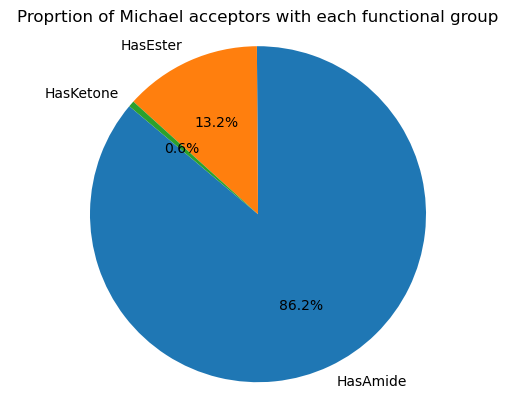

<Figure size 640x480 with 0 Axes>

In [15]:
import matplotlib.pyplot as plt

plt.pie(functional_group_counts, labels=functional_group_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Proprtion of Michael acceptors with each functional group')
plt.axis('equal')
plt.show()
plt.savefig("tranch_00_pichart.png")

